### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
%pip install matplotlib seaborn pandas numpy

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.5 MB 8.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.5 MB 9.0 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 9.6 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 8.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 7.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 6.6 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.7 MB/s  0:00:01
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.0 MB 3.6 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/10.0 MB 5.0 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/10.0 MB 5.6 MB/s eta 0:00:02
   ------------------ ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [4]:
data = pd.read_csv('../data/coupons.csv')

In [5]:
data.head()
data.info()
data.tail(3).T



<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

,12681,12682,12683
destination,Work,Work,Work
passanger,Alone,Alone,Alone
weather,Snowy,Snowy,Sunny
temperature,30,30,80
time,7AM,7AM,7AM
coupon,Coffee House,Bar,Restaurant(20-50)
expiration,1d,1d,2h
gender,Male,Male,Male
age,26,26,26
maritalStatus,Single,Single,Single


2. Investigate the dataset for missing or problematic data.

In [6]:
data.info()
def data_investigate(data):
    data_info = pd.DataFrame(data.dtypes, columns=['Dtype'])
    # check for valid data types
    # Check NaN values with proper values
    all_object_type_cols = data.select_dtypes(exclude=['int64']).columns.tolist()
    print("\nAll data columns", all_object_type_cols)
    # Check Null values with proper numbers
    all_int_type_cols=data.select_dtypes(exclude=['object']).columns.tolist()
    print("\nAll int columns", all_int_type_cols)
    # Check for other violations
    return all_int_type_cols,all_object_type_cols
    
all_int_type_cols,all_object_type_cols = data_investigate(data)   

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

3. Decide what to do about your missing data -- drop, replace, other...

In [7]:
def data_cleaning(data):
# Valid data type
# Replace NaN values with proper values
    data[all_object_type_cols] = data[all_object_type_cols].fillna('No car')    
# Replace Null values with proper numbers
    data[all_int_type_cols] = data[all_int_type_cols].fillna(0)
# Any other meaningful validations
    return data
cleaned_data = data_cleaning(data)
cleaned_data.tail(3).T

,12681,12682,12683
destination,Work,Work,Work
passanger,Alone,Alone,Alone
weather,Snowy,Snowy,Sunny
temperature,30,30,80
time,7AM,7AM,7AM
coupon,Coffee House,Bar,Restaurant(20-50)
expiration,1d,1d,2h
gender,Male,Male,Male
age,26,26,26
maritalStatus,Single,Single,Single


4. What proportion of the total observations chose to accept the coupon?



In [8]:
print(cleaned_data['Y'].mean(), end="\n\n")
#cleaned_data.describe()


0.5684326710816777



5. Use a bar plot to visualize the `coupon` column.

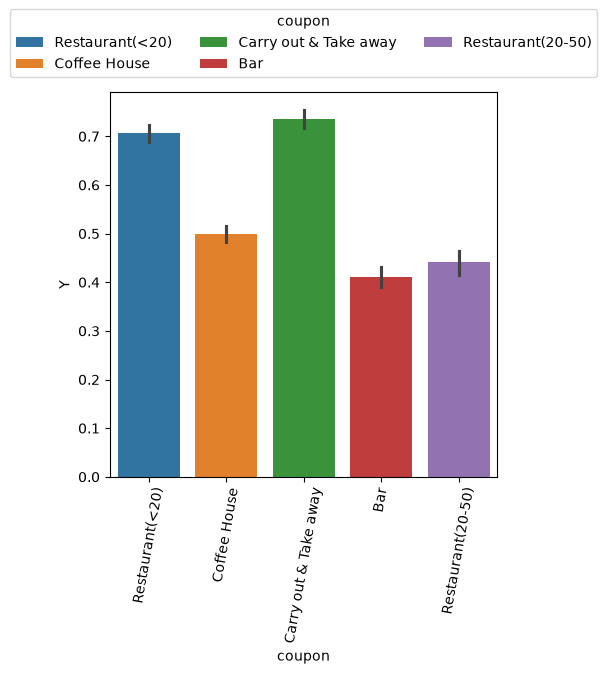

                  coupon  Offered  Accepted
0                    Bar     2017       827
1  Carry out & Take away     2393      1760
2           Coffee House     3996      1995
3      Restaurant(20-50)     1492       658
4        Restaurant(<20)     2786      1970
<class 'pandas.DataFrame'>


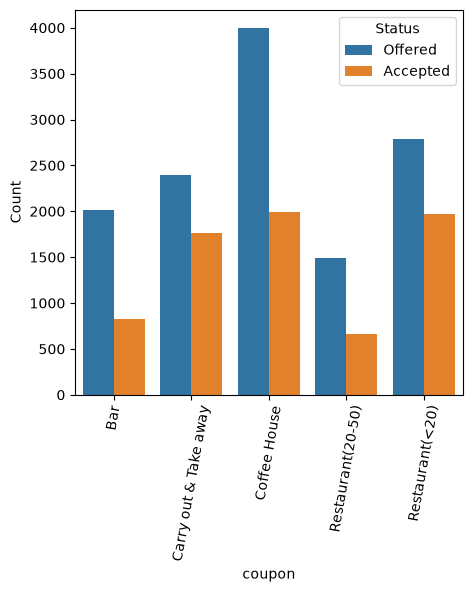

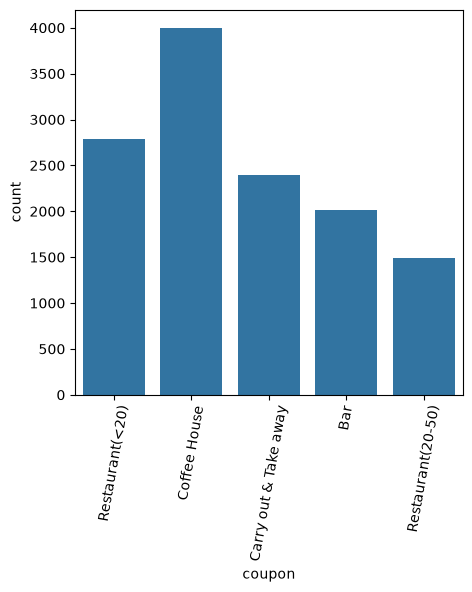

In [20]:
plt.figure(figsize=(5,5))
ax = sns.barplot(data, x="coupon", y="Y", hue="coupon", legend=True)
plt.xticks(rotation=80)
#ax.set_xticklabels(labels='"coupon"]', rotation=30)
#sns.countplot(data, y= 'Y' )
#plt.show()
#ax = sns.barplot(data, x="Y", legend=True)
sns.move_legend(
    ax, 
    loc="lower center",          # Anchors the bottom-middle of the legend box...
   bbox_to_anchor=(0.5, 1.02),  # ...to the top-center (x=0.5, y=1.02) of the plot axes
    ncol=3                       # Arranges legend items in 3 horizontal columns
)

plt.show()

coupons_summary = data.groupby('coupon').agg(Offered=("Y","count"), Accepted=("Y","sum")).reset_index()
print(coupons_summary)
print(type(coupons_summary))
plot_data = coupons_summary.melt(
    id_vars="coupon",
    value_vars=["Offered", "Accepted"],
    var_name="Status",
    value_name="Count"
)
plt.figure(figsize=(5, 5))
ax = sns.barplot(plot_data, x="coupon", y="Count", hue="Status", legend=True)
plt.xticks(rotation=80)
plt.show()

plt.figure(figsize=(5, 5))
ax1 = sns.countplot(data=cleaned_data, x="coupon")
plt.xticks(rotation=80)
plt.show()



6. Use a histogram to visualize the temperature column.

<Axes: xlabel='temperature', ylabel='Count'>

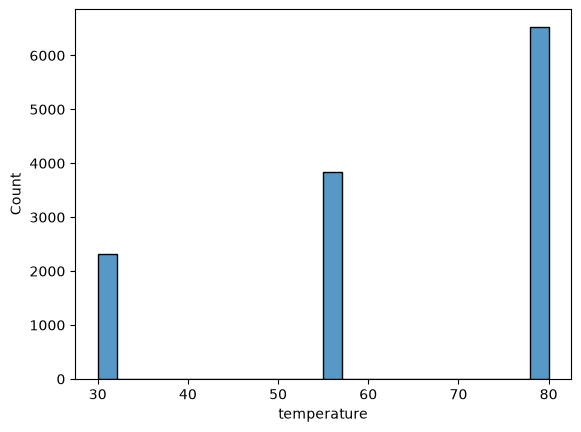

In [21]:
sns.histplot(data,x="temperature",bins='auto')


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [22]:
bar_coupons = cleaned_data[cleaned_data["coupon"] == "Bar"]
bar_coupons

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,No car,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,No car,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,No car,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [23]:
bar_coupons_proportion = bar_coupons["Y"].mean()
bar_coupons_proportion

np.float64(0.41001487357461575)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [24]:

bar_acceptance_rate_3_or_less = bar_coupons[bar_coupons['Bar'].isin(['never','less1','1~3'])]["Y"].mean()
bar_acceptance_rate_4_or_more = bar_coupons[bar_coupons["Bar"].isin(["4~8", "gt8"])]["Y"].mean()
bar_acceptance_rate_3_or_less , bar_acceptance_rate_4_or_more


(np.float64(0.37061769616026713), np.float64(0.7688442211055276))

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [25]:
acceptance_rate_bar_driverover25_morethan1 = bar_coupons[
    bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_coupons['age'].isin(['26', '31', '36', '41', '46', '50plus']))
]['Y'].mean()

acceptance_rate_bar_driverless21_never = bar_coupons[
    bar_coupons['age'].isin(['21']) & 
    (bar_coupons['Bar'].isin(['never','lessthan1']))
    ]['Y'].mean()

acceptance_rate_bar_driverover25_morethan1, acceptance_rate_bar_driverless21_never

(np.float64(0.6952380952380952), np.float64(0.2323943661971831))

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [26]:
acceptance_rate_driverwithnopassengeraskid_notfarmfishforest = bar_coupons[
    bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    ~(bar_coupons['passanger'].isin(['kid(s)'])) &
    ~(bar_coupons['occupation'].isin(['farming','fishery','forestry']))]['Y'].mean()

acceptance_rate_not_driverwithnopassengeraskid_notfarmfishforest = bar_coupons[
    ~((bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    ~(bar_coupons['passanger'].isin(['kid(s)'])) &
    ~(bar_coupons['occupation'].isin(['farming','fishery','forestry'])))]['Y'].mean()

acceptance_rate_driverwithnopassengeraskid_notfarmfishforest , acceptance_rate_not_driverwithnopassengeraskid_notfarmfishforest

(np.float64(0.6879194630872483), np.float64(0.29345531315974666))

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [27]:
print(data["income"].unique())
acceptance_rate = bar_coupons[
    (
		bar_coupons['Bar'].isin(['1~3','4~8','gt8']) &
		~bar_coupons['passanger'].isin(['Kid(s)']) &
		~bar_coupons['maritalStatus'].isin(['widowed'])
                    
    )    
    |
    (
      bar_coupons['Bar'].isin(['1~3','4~8','gt8']) & 
      bar_coupons['age'].isin(['21','26'])
     )
    |
    (
      bar_coupons['RestaurantLessThan20'].isin(['4~8','gt8']) & 
      bar_coupons['income'].isin([
          '$37500 - $49999',
          '$25000 - $37499',
          '$12500 - $24999',
         'Less than $12500'
          

      ])
    )
    ]['Y'].mean()

acceptance_rate

acceptance_rate_for_rest = bar_coupons[
    (~(
		bar_coupons['Bar'].isin(['1~3','4~8','gt8']) &
		~bar_coupons['passanger'].isin(['Kid(s)']) &
		~bar_coupons['maritalStatus'].isin(['widowed'])
                    
    ))    
    &
    (~(
      bar_coupons['Bar'].isin(['1~3','4~8','gt8']) & 
      bar_coupons['age'].isin(['21','26'])
     ))
    &
    (~(
      bar_coupons['RestaurantLessThan20'].isin(['4~8','gt8']) & 
      bar_coupons['income'].isin([
          '$37500 - $49999',
          '$25000 - $37499',
          '$12500 - $24999',
         'Less than $12500'
          

      ])
    )   
    )
    ]['Y'].mean()

acceptance_rate, acceptance_rate_for_rest



<StringArray>
[ '$37500 - $49999',  '$62500 - $74999',  '$12500 - $24999',
  '$75000 - $87499',  '$50000 - $62499',  '$25000 - $37499',
  '$100000 or More',  '$87500 - $99999', 'Less than $12500']
Length: 9, dtype: str


(np.float64(0.5889175257731959), np.float64(0.29814665592264306))

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [33]:
if acceptance_rate > acceptance_rate_for_rest:
    print("We hypothesize that drivers who meet at least one of the three conditions are more likely to accept Bar coupons.")
else:
    print("We hypothesize that drivers who meet at least one of the three conditions are not more likely to accept Bar coupons.")

We hypothesize that drivers who meet at least one of the three conditions are more likely to accept Bar coupons.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

## Analysis of people on higher income bracket

In [29]:
df_coupons_above75k = cleaned_data[cleaned_data['income'].isin(['$75000 - $87499','$87500 - $99999','$100000 or More'])]
df_coupons_75k = cleaned_data[cleaned_data['income'].isin(['$75000 - $87499'])]
df_coupons_above875 = cleaned_data[cleaned_data['income'].isin(['$87500 - $99999','$100000 or More'])]
df_coupons_875 = cleaned_data[cleaned_data['income'].isin(['$87500 - $99999'])]
df_coupons_above100k = cleaned_data[cleaned_data['income'].isin(['$100000 or More'])]

#print(
#        "Count of people above 75k = ", len(df_coupons_above75k),
#        "\nCount of people above 87500 = ", len(df_coupons_above875),
#        "\nCount of people above 100k = ",len(df_coupons_above100k)
#    )
  
#print(
#        "Coupon accepted by people with income above 75k =",(df_coupons_above75k['Y'] == 1).sum(), 
#        "\nCoupon accepted by people with income above 87500  =",(df_coupons_above875['Y'] == 1).sum() ,
#        "\nCoupon accepted by people with income above 100k =",(df_coupons_above100k['Y'] ==1).sum()
#    )

print(
        "Count of people with 75k to 87499 income = ",len(df_coupons_75k),
        "\nCount of people with 87500 to 100000 income = ",len(df_coupons_875),
        "\nCount of people with 100k and above = ",len(df_coupons_above100k)
    
     )



print(
        "Coupon accepted by people with income above 75k to 87499 =",(df_coupons_75k['Y'] == 1).sum(), 
        "\nCoupon accepted by people with income above 87499 to 100000  =",(df_coupons_875['Y'] == 1).sum() ,
        "\nCoupon accepted by people with income above 100000  =",(df_coupons_above100k['Y'] == 1).sum() ,
    
    
)


Count of people with 75k to 87499 income =  857 
Count of people with 87500 to 100000 income =  895 
Count of people with 100k and above =  1736
Coupon accepted by people with income above 75k to 87499 = 414 
Coupon accepted by people with income above 87499 to 100000  = 476 
Coupon accepted by people with income above 100000  = 1004


## This gives coupon acceptance rate of people with income:
## $75,000 - $87,499
## $87,500 - $99,999
## $100,000 or More
## ## <Income> group → acceptance rate

<Axes: xlabel='Income', ylabel='AcceptanceRate'>

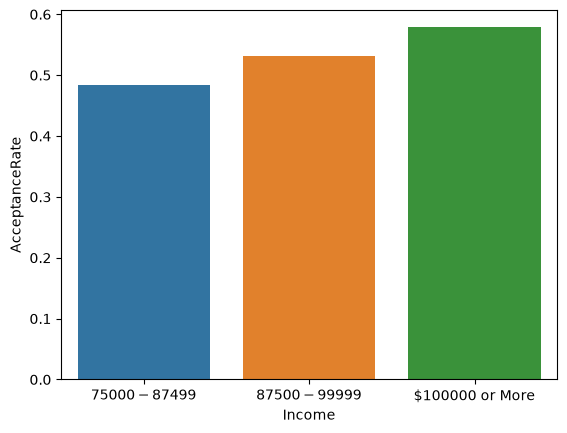

In [30]:
combined_acceptance_rate_for_all_above75k = pd.DataFrame( 
                                                            {
                                                            "Income": ['$75000 - $87499','$87500 - $99999','$100000 or More'],
                                                            "AcceptanceRate" : [(df_coupons_75k['Y'] == 1).mean(),
                                                                               (df_coupons_875['Y'] == 1).mean(),
                                                                               (df_coupons_above100k['Y'] == 1).mean(),]
                                                            }
                                                        )

sns.barplot(data=combined_acceptance_rate_for_all_above75k,x="Income",y="AcceptanceRate", hue="Income")

## This gives coupon acceptance rate of people with income highter than 100k and 
## who goes to CoffeHouse
## who does CarryAway  
## who goes to Restaurant20To50
## who goes to BAR
## <Location> frequency → acceptance rate

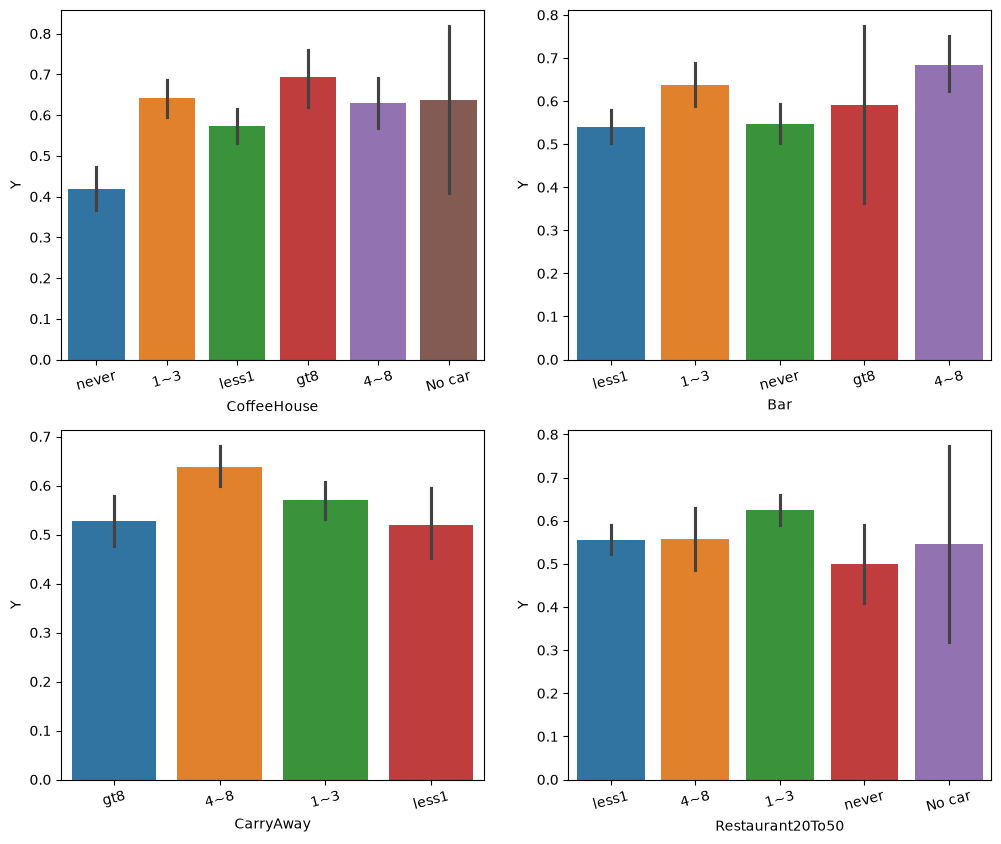

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.barplot(data=df_coupons_above100k, x="CoffeeHouse", y="Y", ax=axes[0,0],hue="CoffeeHouse")
sns.barplot(data=df_coupons_above100k, x="Bar", y="Y", ax=axes[0,1],hue="Bar")
sns.barplot(data=df_coupons_above100k, x="CarryAway", y="Y", ax=axes[1,0],hue="CarryAway")
sns.barplot(data=df_coupons_above100k, x="Restaurant20To50", y="Y", ax=axes[1,1],hue='Restaurant20To50')
for ax in axes.flat:
    ax.tick_params(axis="x", labelrotation=15)
#plt.tight_layout()
plt.show()

## This gives coupon acceptance rate of people with income highter than 100k and 
## who goes to Bar  AND CoffeHouse
## who does CarryAway AND RestaurantLessThan20
## who goes to Bar AND Restaurant20To50
## who goes to CoffeeHouse AND CoffeeHouse
## <Location> frequency + <Location> frequency → acceptance rate

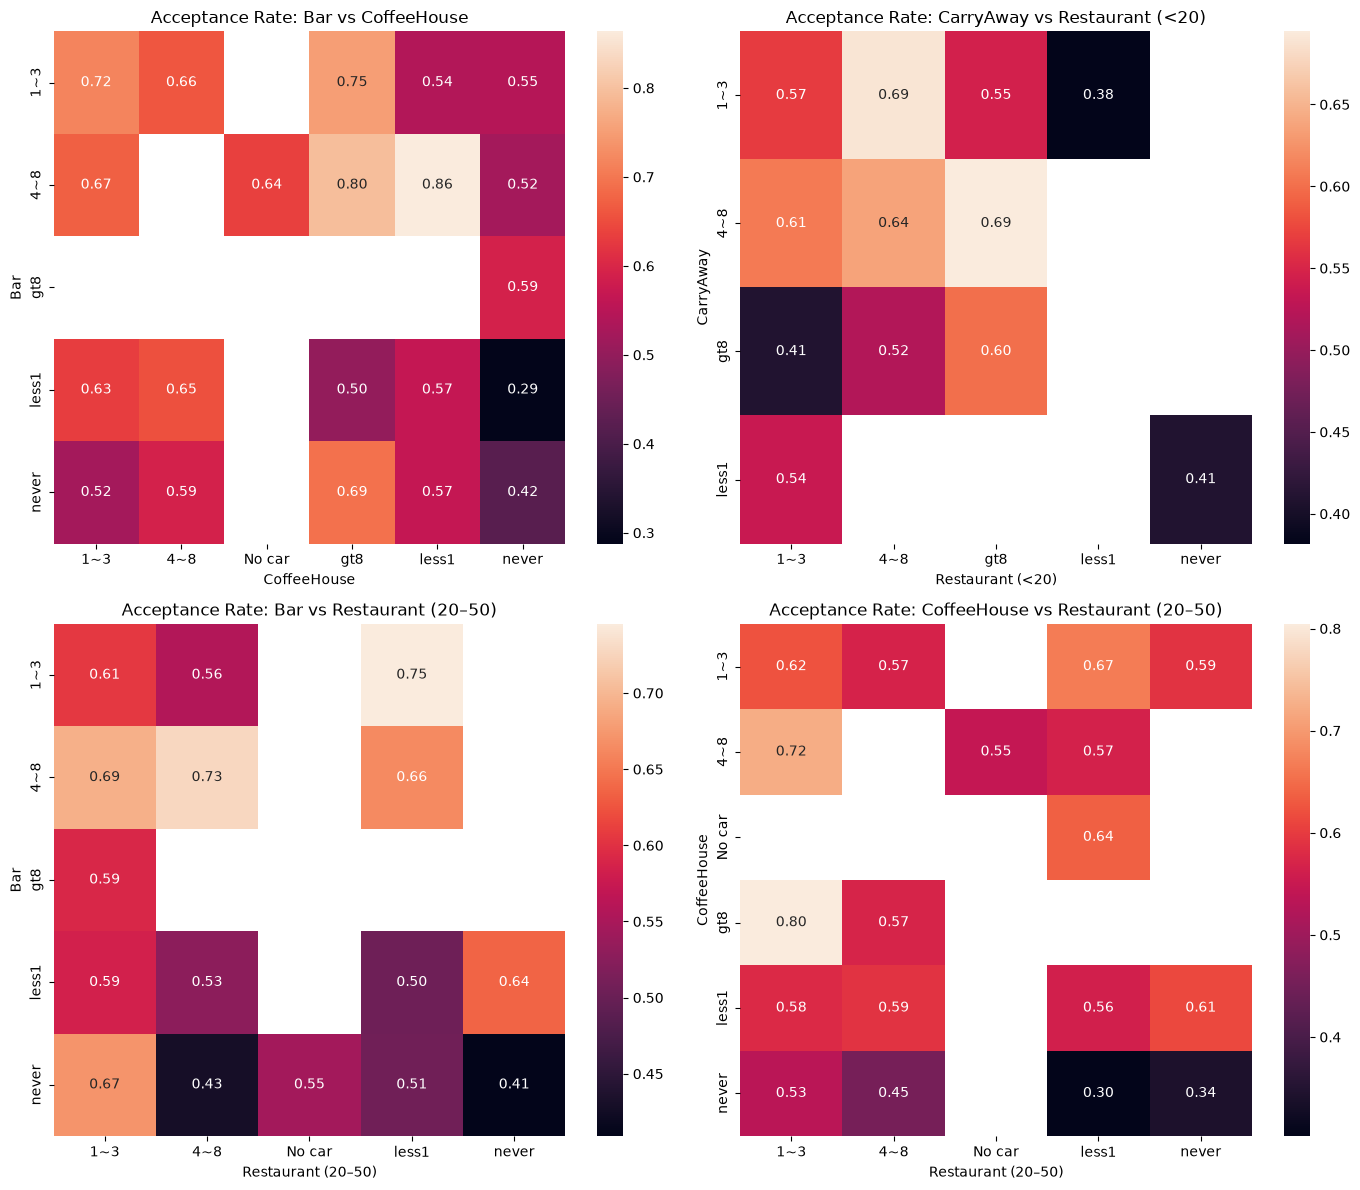

In [32]:

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Bar + CoffeeHouse
pivot1 = df_coupons_above100k.pivot_table(
    values="Y",
    index="Bar",
    columns="CoffeeHouse",
    aggfunc="mean"
)
sns.heatmap(pivot1, annot=True, fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title("Acceptance Rate: Bar vs CoffeeHouse")
axes[0, 0].set_xlabel("CoffeeHouse")
axes[0, 0].set_ylabel("Bar")


# 2. CarryAway + RestaurantLessThan20
pivot2 = df_coupons_above100k.pivot_table(
    values="Y",
    index="CarryAway",
    columns="RestaurantLessThan20",
    aggfunc="mean"
)
sns.heatmap(pivot2, annot=True, fmt=".2f", ax=axes[0, 1])
axes[0, 1].set_title("Acceptance Rate: CarryAway vs Restaurant (<20)")
axes[0, 1].set_xlabel("Restaurant (<20)")
axes[0, 1].set_ylabel("CarryAway")


# 3. Bar + Restaurant20To50
pivot3 = df_coupons_above100k.pivot_table(
    values="Y",
    index="Bar",
    columns="Restaurant20To50",
    aggfunc="mean"
)
sns.heatmap(pivot3, annot=True, fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("Acceptance Rate: Bar vs Restaurant (20–50)")
axes[1, 0].set_xlabel("Restaurant (20–50)")
axes[1, 0].set_ylabel("Bar")


# 4. CoffeeHouse + Restaurant20To50
pivot4 = df_coupons_above100k.pivot_table(
    values="Y",
    index="CoffeeHouse",
    columns="Restaurant20To50",
    aggfunc="mean"
)
sns.heatmap(pivot4, annot=True, fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Acceptance Rate: CoffeeHouse vs Restaurant (20–50)")
axes[1, 1].set_xlabel("Restaurant (20–50)")
axes[1, 1].set_ylabel("CoffeeHouse")


plt.tight_layout()
plt.show()

In [34]:
combined_data = pd.concat([
    df_coupons_75k,
    df_coupons_875,
    df_coupons_above100k
])

In [36]:
contingency_table = pd.crosstab(
    combined_data['income'],
    combined_data['Y']
)

print(contingency_table)

Y                  0     1
income                    
$100000 or More  732  1004
$75000 - $87499  443   414
$87500 - $99999  419   476


In [37]:
%pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.3 MB 8.2 MB/s eta 0:00:05
   --- ------------------------------------ 2.9/37.3 MB 7.1 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/37.3 MB 7.1 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/37.3 MB 6.9 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/37.3 MB 5.9 MB/s eta 0:00:06
   -------- ------------------------------- 7.6/37.3 MB 6.2 MB/s eta 0:00:05
   ---------- ----------------------------- 9.7/37.3 MB 6.7 MB/s eta 0:00:05
   ----------- ---------------------------- 11.0/37.3 MB 6.7 MB/s eta 0:00:04
   ------------ --------------------------- 11.8/37.3 MB 6.5 MB/s eta 0:00:04
   ------------- -------------------------- 12.6/37.3 MB 6.1 MB/s eta 0:00:05
   -------------- ------------------------- 13.4/37.3 MB 5.9 MB/s eta 0:00:05
   --------------- ------------------------ 14.2/37.3 MB 5.7 MB/s eta 0:00:05
 


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p_value)

Chi-square: 21.585940728289998
p-value: 2.054340970358878e-05


In [39]:
if p_value < 0.05:
    print("There is a statistically significant association between income group and coupon acceptance.")
else:
    print("There is not enough evidence of a statistically significant association between income group and coupon acceptance.")

There is a statistically significant association between income group and coupon acceptance.
